# Numerisk derivasjon, lister og arrays

**INGA1002 · 16. september 2026 · Jonas J. Harang**

Basert på undervisningsmateriale av Kai Erik Hoff og Truls Helge Øi.

Dette er en **ferdig utfylt forelesningsnotebook**. Alle eksemplene kan kjøres
ovenfra og ned. Endre gjerne verdier og undersøk hva som skjer.

**Målet:** bruke Python til å beregne og undersøke numeriske tilnærminger til
den deriverte. Lister, arrays og plotting er verktøyene vi trenger underveis.

- [Kort oppsummering fra lysbildene](#fra-fart-til-derivert)
- [Her starter programmeringsdelen](#programmering)
- [Lister og indeksering](#lister)
- [NumPy-arrays og elementvise beregninger](#arrays)
- [Lage mange verdier: arange og linspace](#tallrekker)
- [Plotting og numerisk derivasjon](#plotting)
- [Absolutt og relativ feil](#feil)
- [Oppsummering og veien videre](#oppsummering)

[Lysbilder](https://jonajh.folk.ntnu.no/INGA1002/forelesning/03-numerisk-derivasjon/)
· [Interaktiv aktivitet](https://jonajh.folk.ntnu.no/INGA1002/aktiviteter/numerisk-derivasjon/)

Bildene er vedlagt i selve notebookfilen. Python-eksemplene krever bare NumPy og Matplotlib.

<a id="fra-fart-til-derivert"></a>
## Fra fart til derivert

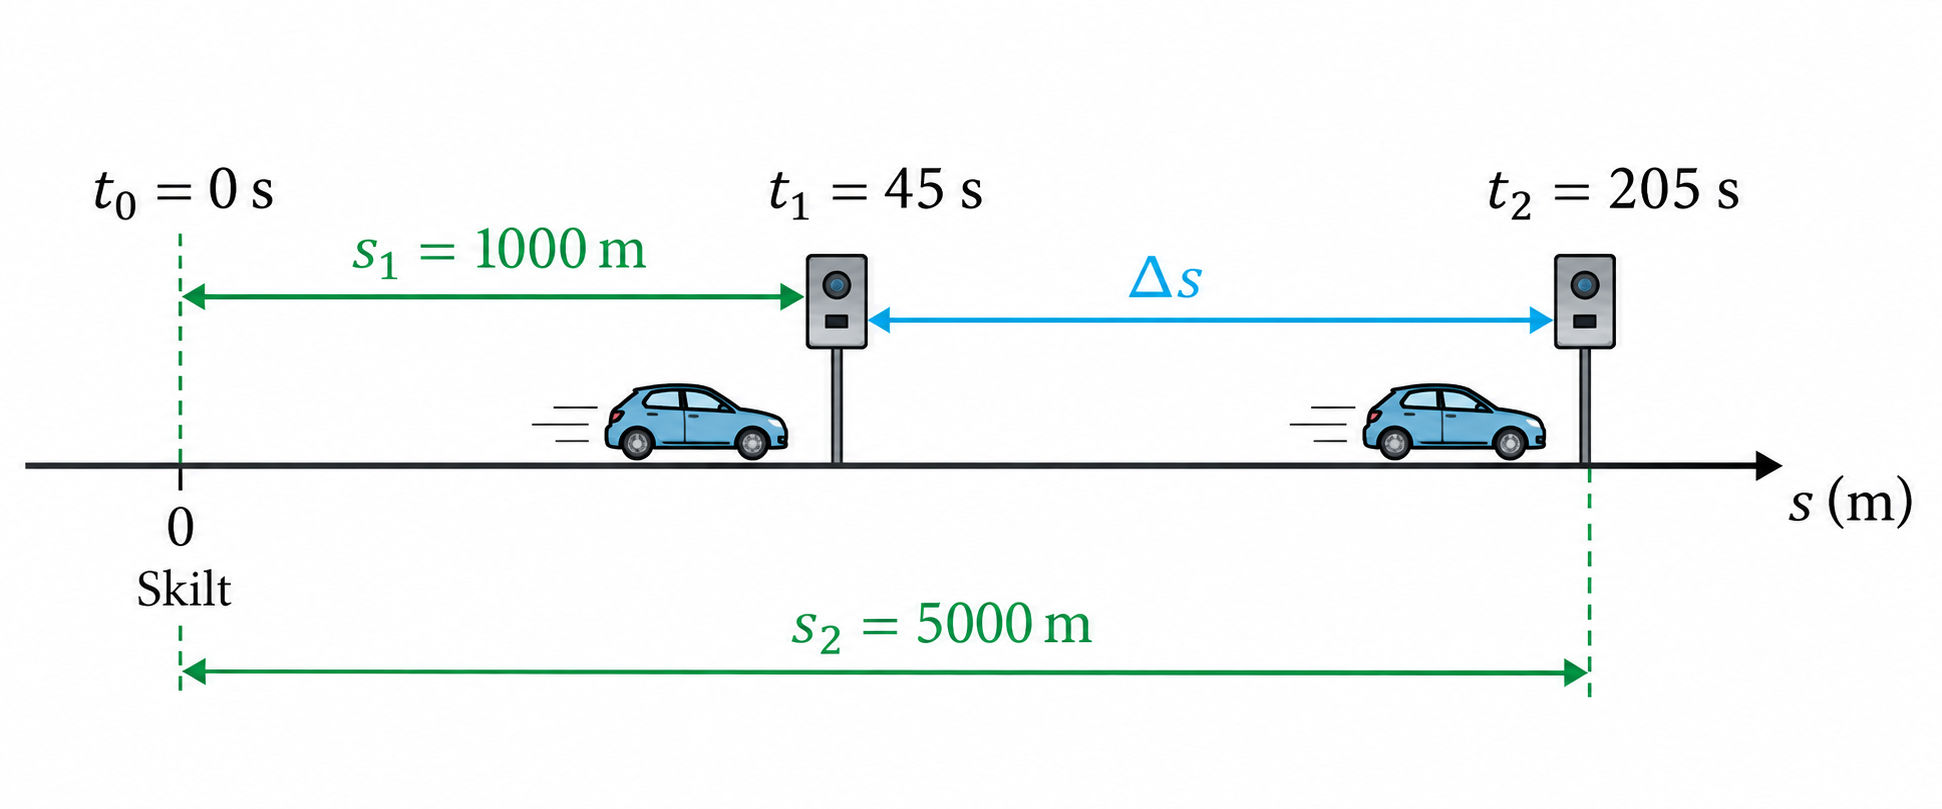

Bilen passerer den første fotoboksen ved $s_1=1000\ \mathrm{m}$ og
$t_1=45\ \mathrm{s}$, og den andre ved $s_2=5000\ \mathrm{m}$ og
$t_2=205\ \mathrm{s}$.

$$
\Delta s=s_2-s_1=4000\ \mathrm{m},\qquad
\Delta t=t_2-t_1=160\ \mathrm{s}.
$$

Gjennomsnittsfarten mellom fotoboksene blir

$$
v_{\mathrm{snitt}}=\frac{\Delta s}{\Delta t}
=\frac{4000\ \mathrm{m}}{160\ \mathrm{s}}
=25\ \mathrm{m/s}=90\ \mathrm{km/t}.
$$

Dette er et gjennomsnitt over fire kilometer. Det forteller ikke hvor fort
bilen kjørte på hvert enkelt sted underveis.


### Et kort måleintervall

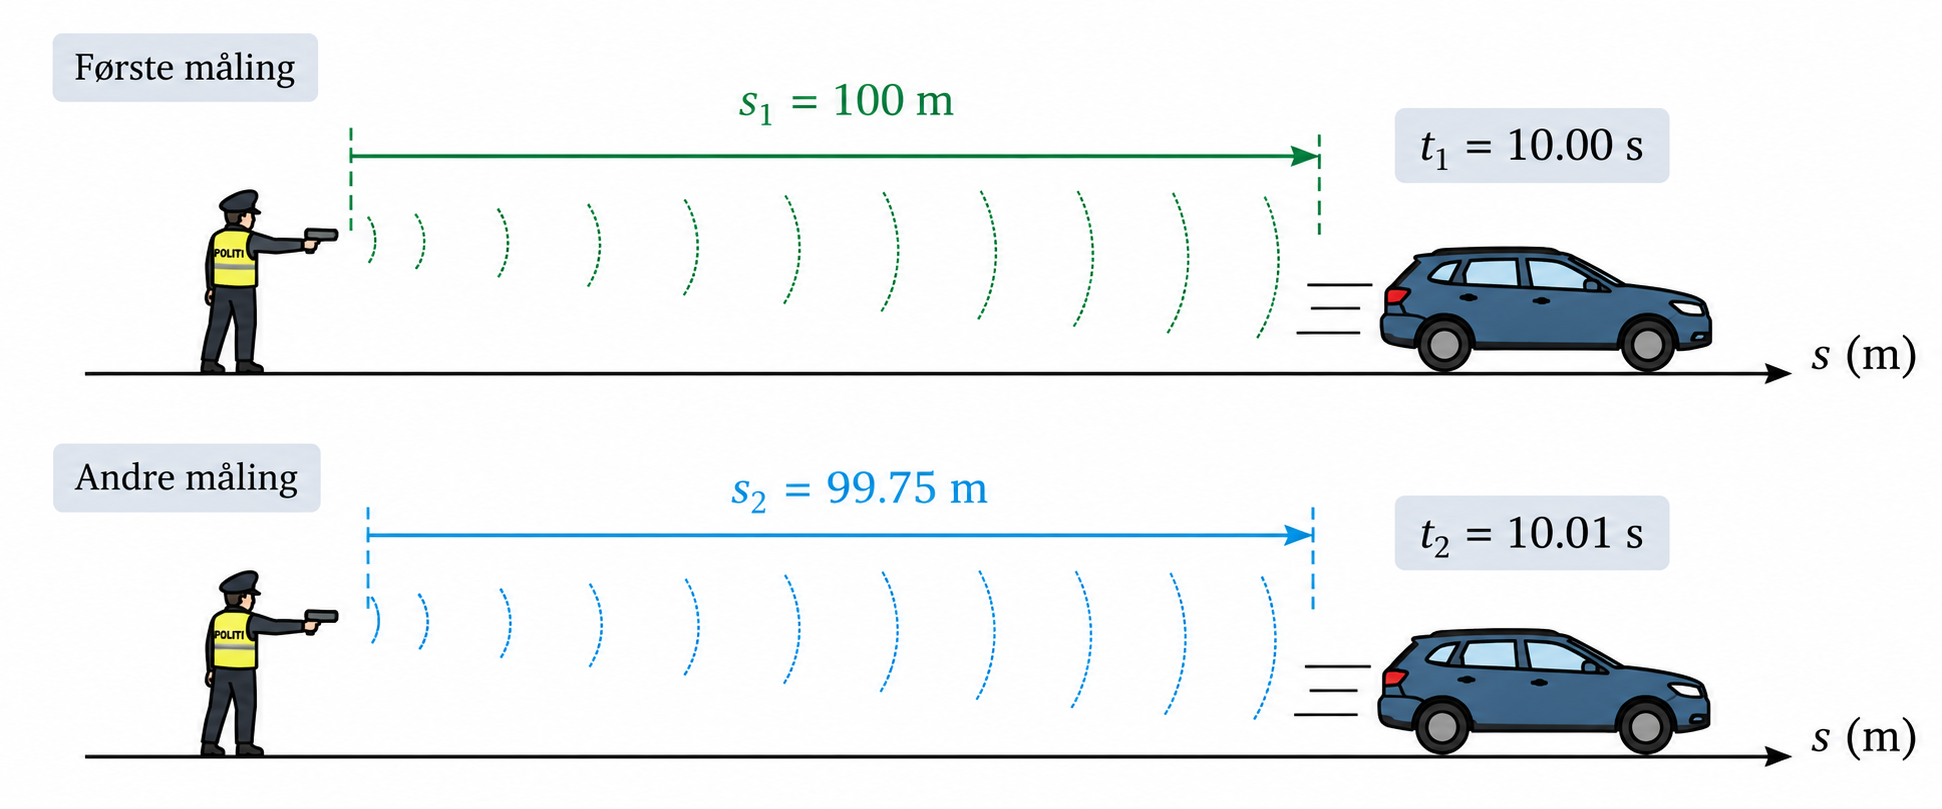

I dette idealiserte eksempelet måles avstanden til bilen to ganger med
$0{,}01\ \mathrm{s}$ mellomrom:

$$
\Delta s=99{,}75-100{,}00=-0{,}25\ \mathrm{m},\qquad
\Delta t=10{,}01-10{,}00=0{,}01\ \mathrm{s}.
$$

$$
\frac{\Delta s}{\Delta t}=-25\ \mathrm{m/s}.
$$

Minustegnet betyr at avstanden fra måleren til bilen minker. Bilens fart er
tallverdien $25\ \mathrm{m/s}=90\ \mathrm{km/t}$. Når tidsintervallet er kort,
gir gjennomsnittet et anslag for farten akkurat da.


### Radar, laser og modellen vår

En radar bruker Doppler-effekten. En laserbasert fartsmåler kan bruke gjentatte
avstandsmålinger. Vi arbeider videre med det numeriske spørsmålet som oppstår
når vi kjenner posisjon eller avstand ved ulike tidspunkt.

Hvis posisjonen er $s(t)$, er momentanhastigheten den deriverte:

$$
s'(t)=\lim_{h\to0}\frac{s(t+h)-s(t)}{h}.
$$

På en datamaskin bruker vi en endelig skrittlengde $h>0$ og beregner en
tilnærming. Det trenger vi særlig når vi bare har måledata eller beregnede
funksjonsverdier, og ikke en formel vi kan derivere direkte.


### Tre differansemetoder

| Metode | Tilnærming til $s'(t)$ | Tidsintervall |
|---|---|---|
| Foroverdifferanse | $\dfrac{s(t+h)-s(t)}{h}$ | fra $t$ til $t+h$ |
| Bakoverdifferanse | $\dfrac{s(t)-s(t-h)}{h}$ | fra $t-h$ til $t$ |
| Senterdifferanse | $\dfrac{s(t+h)-s(t-h)}{2h}$ | fra $t-h$ til $t+h$ |

For senterdifferanse er avstanden mellom målepunktene **$2h$**.
I en posisjonsgraf er hastigheten stigningen, ikke høyden på grafen.

[Utforsk sekant og tangent i aktiviteten](https://jonajh.folk.ntnu.no/INGA1002/aktiviteter/numerisk-derivasjon/).

### Regneeksempel 1: $s(t)=5t^2$

Med $t=1$ og $h=0{,}2$ får vi:

$$s(0{,}8)=3{,}2,\qquad s(1)=5,\qquad s(1{,}2)=7{,}2.$$

$$
\begin{aligned}
v_{\mathrm{forover}}&=\frac{7{,}2-5}{0{,}2}=11\ \mathrm{m/s},\\
v_{\mathrm{bakover}}&=\frac{5-3{,}2}{0{,}2}=9\ \mathrm{m/s},\\
v_{\mathrm{senter}}&=\frac{7{,}2-3{,}2}{0{,}4}=10\ \mathrm{m/s}.
\end{aligned}
$$

Eksakt: $s'(1)=10\ \mathrm{m/s}$. Senterdifferansen er eksakt for denne
andregradsfunksjonen. Det gjelder ikke alle funksjoner.

### Regneeksempel 2: $f(x)=x^3$

Ved $x=1$ og $h=0{,}2$:

$$f(0{,}8)=0{,}512,\qquad f(1)=1,\qquad f(1{,}2)=1{,}728.$$

$$
\begin{aligned}
D_+f(1)&=\frac{1{,}728-1}{0{,}2}=3{,}64,\\
D_-f(1)&=\frac{1-0{,}512}{0{,}2}=2{,}44,\\
D_0f(1)&=\frac{1{,}728-0{,}512}{0{,}4}=3{,}04.
\end{aligned}
$$

Eksakt: $f'(1)=3$. Senterdifferansen er nærmest, men feilen er $0{,}04$.

<a id="programmering"></a>
## Her starter programmeringsdelen

Vi begynner med den samme funksjonen og det samme punktet som i håndregningen.

**Husk:** <code>def</code> definerer funksjonen; et funksjonskall utfører beregningen;
<code>return</code> gir verdien tilbake. <code>**</code> betyr potens.

In [2]:
def f(x):
    return x**3

x = 1.0
h = 0.2
print(f(x))

1.0


### Én formel → én kodelinje

Foroverdifferanse:

In [3]:
derivert_forover = (f(x + h) - f(x)) / h
print(f"Forover: {derivert_forover:.2f}")

Forover: 3.64


Bakover- og senterdifferanse:

In [4]:
derivert_bakover = (f(x) - f(x - h)) / h
derivert_senter = (f(x + h) - f(x - h)) / (2 * h)
eksakt = 3 * x**2

print(f"Bakover: {derivert_bakover:.2f}")
print(f"Senter:  {derivert_senter:.2f}")
print(f"Eksakt:  {eksakt:.2f}")

Bakover: 2.44
Senter:  3.04
Eksakt:  3.00


**Stopp og prøv:** Sett $h=0{,}1$, kjør de tre cellene på nytt, og sammenlign.
Hva må kjøres om igjen når du endrer en variabel?

<details><summary>Forventet resultat ved x = 1 og h = 0,1</summary>
Forover: 3,31. Bakover: 2,71. Senter: 3,01. Eksakt: 3,00.
</details>

### Vi har allerede sett at én funksjon kan behandle mange verdier

I forrige forelesning ble kastelengden beregnet for flere vinkler samtidig.
Her gjør vi det samme med vår enklere funksjon.
Vi forklarer straks hva <code>np.array</code> gjør.

In [5]:
import numpy as np

x_verdier = np.array([0.8, 1.0, 1.2])
print(f(x_verdier))

[0.512 1.    1.728]


Én funksjon, tre inputverdier, tre outputverdier.
For å forstå dette tar vi først et skritt tilbake: Hvordan lagrer vi flere verdier?

<a id="lister"></a>
## Lister: én variabel, flere verdier

Tenk at vi har målt posisjonen til bilen ved tre tidspunkt.
Dette er konstruerte eksempeldata fra modellen $s(t)=5t^2$, ikke et virkelig forsøk.
Listene hører sammen **element for element**.

In [6]:
tider = [0.8, 1.0, 1.2]       # sekunder
posisjoner = [3.2, 5.0, 7.2]  # meter
print(tider)
print(posisjoner)

[0.8, 1.0, 1.2]
[3.2, 5.0, 7.2]


### Indekseringen begynner på null

| Indeks | 0 | 1 | 2 |
|---|---:|---:|---:|
| Tid (s) | 0,8 | 1,0 | 1,2 |
| Posisjon (m) | 3,2 | 5,0 | 7,2 |

Klammeparentesene brukes både til å lage listen og til å hente et element.

In [7]:
print(tider[1])
print(posisjoner[1])
print(posisjoner[-1])  # siste element
print(len(posisjoner))

1.0
5.0
7.2
3


### Derivasjon fra målinger

Bruk den faktiske tidsforskjellen mellom målepunktene i nevneren.

In [8]:
fart_forover = (posisjoner[2] - posisjoner[1]) / (tider[2] - tider[1])
fart_bakover = (posisjoner[1] - posisjoner[0]) / (tider[1] - tider[0])
fart_senter = (posisjoner[2] - posisjoner[0]) / (tider[2] - tider[0])

print(f"Forover: {fart_forover:.1f} m/s")
print(f"Bakover: {fart_bakover:.1f} m/s")
print(f"Senter:  {fart_senter:.1f} m/s")

Forover: 11.0 m/s
Bakover: 9.0 m/s
Senter:  10.0 m/s


**Kontrollspørsmål:** Hvilken tid anslår vi hastigheten ved med senterdifferansen?

<details><summary>Svar</summary>
Ved 1,0 s, midt mellom 0,8 s og 1,2 s. Hele tidsintervallet er 0,4 s.
</details>

### Et element kan endres

Vi bruker en egen liten liste, slik at måledataene over beholdes.

In [9]:
navn = ["Ada", "Kai", "Truls"]
navn[1] = "Jonas"
print(navn)
print(navn[-2])

['Ada', 'Jonas', 'Truls']
Jonas


En liste kan inneholde både tall og tekst.

**Prøv:** Lag listen [2, 4, 6, 8]. Hent siste element, og bytt nest siste element
med teksten "A". Hvilken indeks trenger du?

In [10]:
eksempel = [2, 4, 6, 8]
print(eksempel[-1])
eksempel[-2] = "A"
print(eksempel)

8
[2, 4, 'A', 8]


<a id="arrays"></a>
## Hvorfor NumPy-arrays?

Vi ønsker å regne med mange tall samtidig. Men regneoperatorene betyr
ikke alltid det vi ønsker for en Python-liste.

**Gjett resultatet før du kjører:**

In [11]:
liste = [1, 2, 3]
print(liste * 2)
print(liste + liste)

[1, 2, 3, 1, 2, 3]
[1, 2, 3, 1, 2, 3]


<code>*</code> gjentar listen, og <code>+</code> setter lister sammen.
Uttrykket <code>liste - 1</code> ville gitt en TypeError.

Et NumPy-array er laget for numeriske beregninger:

In [12]:
array = np.array([1, 2, 3])
print(array * 2)
print(array + array)
print(array - 1)
print(array**2)

[2 4 6]
[2 4 6]
[0 1 2]
[1 4 9]


### Elementvis betyr at hvert tall blir behandlet

For eksempel gir <code>array**2</code> kvadratet av hvert element.
Også NumPy-funksjoner som <code>np.sin</code>, <code>np.cos</code> og <code>np.exp</code> virker elementvis.

Et vanlig numerisk array har én felles datatype for elementene.
NumPy kan konvertere inputverdier til en felles type når arrayet lages.

In [13]:
print(type(array))
print(array.dtype)
print(np.array([1, 2.5, 3]))

<class 'numpy.ndarray'>
int64
[1.  2.5 3. ]


### To arrays kan regnes sammen

Her bruker vi endimensjonale arrays med samme lengde.

In [14]:
a = np.array([2, 4, 6])
b = np.array([1, 2, 3])

print(a + b)
print(a * b)
print(a / b)

[3 6 9]
[ 2  8 18]
[2. 2. 2.]


**Kontrollspørsmål:** Er <code>a * b</code> én samlet multiplikasjon av vektorer,
eller tre separate multiplikasjoner?

<details><summary>Svar</summary>
Tre separate multiplikasjoner: 2·1, 4·2 og 6·3. Resultatet er et array.
</details>

### Funksjonen vår virker også på et array

Funksjonen trenger ingen løkke: <code>x**3</code> virker elementvis når x er et array.
Dette gjelder fordi operasjonene i funksjonen støtter arrays.

In [15]:
def f(x):
    return x**3

print(f(2.0))
print(f(np.array([0.0, 1.0, 2.0])))

8.0
[0. 1. 8.]


<a id="tallrekker"></a>
## Mange x-verdier uten å skrive alle selv

<code>np.arange(start, stop, steg)</code> bruker en **steglengde**.
Sluttgrensen er ikke med i heltallseksempelet under.

In [16]:
heltall = np.arange(-2, 6, 1)
print(heltall)
print(len(heltall))

[-2 -1  0  1  2  3  4  5]
8


<code>np.linspace(start, stop, antall)</code> bruker **antall punkter**.
Begge endepunktene er med når vi bruker standardinnstillingene.

In [17]:
punkter = np.linspace(-2, 5, 8)
print(punkter)
print(len(punkter))

[-2. -1.  0.  1.  2.  3.  4.  5.]
8


### Antall punkter er ikke antall intervaller

På intervallet $[0,1]$ gir tre punkter bare to mellomrom:

$$0\quad\longrightarrow\quad0{,}5\quad\longrightarrow\quad1.$$

For $N$ jevnt fordelte punkter fra $a$ til $b$:

$$\Delta x=\frac{b-a}{N-1}.$$

In [18]:
punkter = np.linspace(0, 1, 3)
print(punkter)
print(punkter[1] - punkter[0])

[0.  0.5 1. ]
0.5


**Prøv:** Hvor mange punkter trenger vi fra og med 0 til og med 10
med avstand 0,1 mellom punktene?

<details><summary>Svar</summary>
100 intervaller, altså 101 punkter.
</details>

In [19]:
punkter = np.linspace(0, 10, 101)
print(len(punkter))
print(punkter[0], punkter[-1])
print(punkter[1] - punkter[0])

101
0.0 10.0
0.1


### En liten NumPy-verktøykasse

| Verktøy | Eksempel | Bruk |
|---|---|---|
| np.array | np.array([1, 2, 3]) | Lag array fra verdier |
| np.arange | np.arange(0, 6, 2) | Verdier med valgt steg |
| np.linspace | np.linspace(0, 1, 11) | Valgt antall jevnt fordelte punkter |
| np.zeros | np.zeros(4) | Fire nuller |
| np.ones | np.ones(4) | Fire enere |
| np.sin, np.cos | np.sin(x) | Trigonometriske funksjoner, vinkler i radianer |
| np.exp | np.exp(x) | $e^x$ |
| np.abs | np.abs(x) | Absoluttverdi elementvis |

Når vi vil ha et bestemt antall punkter og bestemte endepunkter, bruker vi
linspace. Ved flyttallssteg i arange kan avrunding påvirke hvilke verdier som kommer med.

In [20]:
print(np.zeros(4))
print(17 * np.ones(4))
print(np.cos(np.array([0, np.pi / 2, np.pi])))

[0. 0. 0. 0.]
[17. 17. 17. 17.]
[ 1.000000e+00  6.123234e-17 -1.000000e+00]


<a id="plotting"></a>
## Fra arrays til en figur

Vi har et array med x-verdier. Funksjonen gir et like langt array med y-verdier.
<code>plt.plot(x, y)</code> forbinder de tilhørende punktene med rette linjestykker.

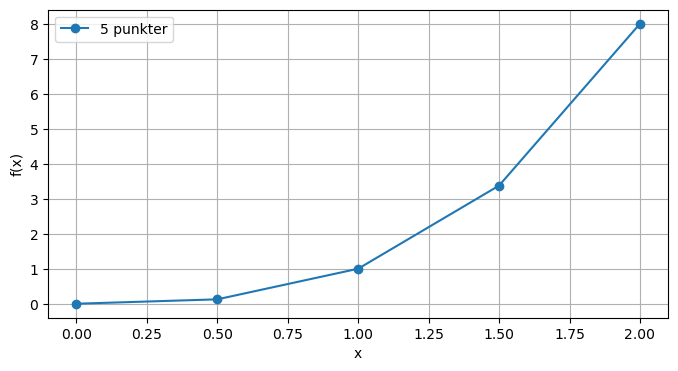

In [21]:
import matplotlib.pyplot as plt

x = np.linspace(0, 2, 5)
y = f(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, "o-", label="5 punkter")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()

### Hvorfor er kurven kantete?

Vi trenger flere punkter for å tegne funksjonen mer detaljert.
Her er to fremstillinger av **samme** funksjon.

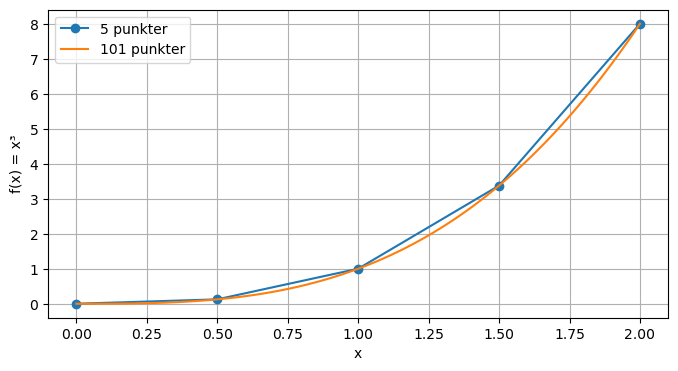

In [22]:
x_faa = np.linspace(0, 2, 5)
x_mange = np.linspace(0, 2, 101)

plt.figure(figsize=(8, 4))
plt.plot(x_faa, f(x_faa), "o-", label="5 punkter")
plt.plot(x_mange, f(x_mange), label="101 punkter")
plt.xlabel("x")
plt.ylabel("f(x) = x³")
plt.legend()
plt.grid()
plt.show()

**Kontrollspørsmål:** Har funksjonen endret seg, eller bare hvor tett vi tegner den?

### Ett øyeblikk med feilsøking

Hvis x har tre elementer og y har fire, kan de ikke pares punkt for punkt.
Da forteller siste linje i feilmeldingen at lengdene ikke passer sammen.

Undersøk <code>len(x)</code> og <code>len(y)</code> før du endrer formelen.

In [23]:
x_test = np.array([0, 1, 2])
y_test = np.array([0, 1, 4, 9])
print(f"Antall x-verdier: {len(x_test)}")
print(f"Antall y-verdier: {len(y_test)}")

# Reparert eksempel: tre tilhørende verdier.
y_test = x_test**2
print(f"Etter retting: {len(x_test)} x-verdier og {len(y_test)} y-verdier")

Antall x-verdier: 3
Antall y-verdier: 4
Etter retting: 3 x-verdier og 3 y-verdier


## Samme differanseformel, mange x-verdier

Vi bruker fortsatt $f(x)=x^3$, med eksakt derivert $f'(x)=3x^2$.
Nå lar vi x være et array.

In [24]:
x = np.linspace(0, 2, 101)
h = 0.2

eksakt = 3 * x**2
forover = (f(x + h) - f(x)) / h
bakover = (f(x) - f(x - h)) / h
senter = (f(x + h) - f(x - h)) / (2 * h)

### To forskjellige avstander

- **Punktavstanden i x** bestemmer hvor tett vi undersøker og tegner resultatet.
- **Skrittlengden h** bestemmer hvilke nabopunkter differanseformelen bruker.

Vi kan beregne <code>f(x + h)</code> direkte fordi vi kjenner funksjonsuttrykket.
Med et målt datasett har vi bare de tidspunktene det faktisk er målt på.

In [25]:
print(f"Punktavstand i x-arrayet: {x[1] - x[0]:.2f}")
print(f"Skrittlengde i differanseformelen: {h:.2f}")
print(f"Antall verdier i forover-arrayet: {len(forover)}")

Punktavstand i x-arrayet: 0.02
Skrittlengde i differanseformelen: 0.20
Antall verdier i forover-arrayet: 101


### Sammenlign med den eksakte deriverte

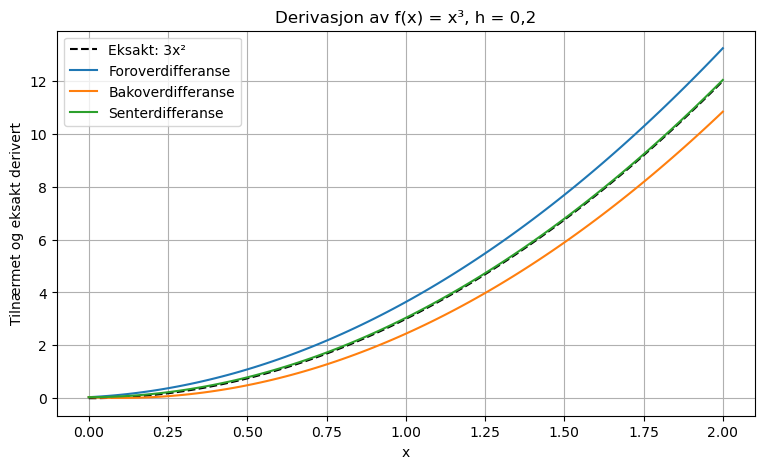

In [26]:
plt.figure(figsize=(9, 5))
plt.plot(x, eksakt, "k--", label="Eksakt: 3x²")
plt.plot(x, forover, label="Foroverdifferanse")
plt.plot(x, bakover, label="Bakoverdifferanse")
plt.plot(x, senter, label="Senterdifferanse")
plt.xlabel("x")
plt.ylabel("Tilnærmet og eksakt derivert")
plt.title("Derivasjon av f(x) = x³, h = 0,2")
plt.legend()
plt.grid()
plt.show()

**Snakk sammen:** Hvilken metode ligger nærmest den eksakte kurven?
Er det lett å se forskjellen mellom senterdifferansen og den eksakte verdien?

<a id="feil"></a>
## Absolutt feil

Når vi kjenner den eksakte deriverte, kan vi måle avviket:

$$\text{absolutt feil}=\left|\text{tilnærmet derivert}-\text{eksakt derivert}\right|.$$

<code>np.abs</code> gjør dette elementvis.

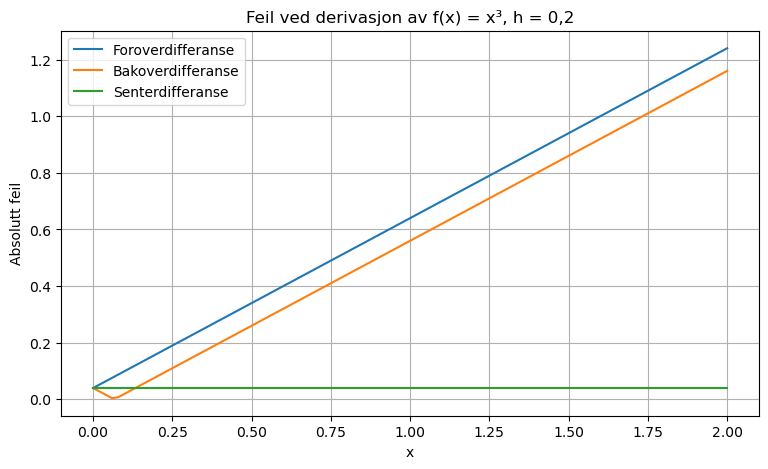

In [27]:
feil_forover = np.abs(forover - eksakt)
feil_bakover = np.abs(bakover - eksakt)
feil_senter = np.abs(senter - eksakt)

plt.figure(figsize=(9, 5))
plt.plot(x, feil_forover, label="Foroverdifferanse")
plt.plot(x, feil_bakover, label="Bakoverdifferanse")
plt.plot(x, feil_senter, label="Senterdifferanse")
plt.xlabel("x")
plt.ylabel("Absolutt feil")
plt.title("Feil ved derivasjon av f(x) = x³, h = 0,2")
plt.legend()
plt.grid()
plt.show()

For akkurat $f(x)=x^3$ er senterdifferansens feil $h^2$,
uavhengig av $x$, når vi ser bort fra flyttallsavrunding.
Det forklarer den vannrette kurven. Feilen er ikke konstant for alle funksjoner.

### Et lite eksperiment: endre h, behold x

Vi sammenligner senterdifferanse ved ett fast punkt.

In [28]:
x0 = 1.0
h_stor = 0.2
h_liten = 0.1

d_stor = (f(x0 + h_stor) - f(x0 - h_stor)) / (2 * h_stor)
d_liten = (f(x0 + h_liten) - f(x0 - h_liten)) / (2 * h_liten)
print(f"Feil med h = 0,2: {abs(d_stor - 3 * x0**2):.4f}")
print(f"Feil med h = 0,1: {abs(d_liten - 3 * x0**2):.4f}")

Feil med h = 0,2: 0.0400
Feil med h = 0,1: 0.0100


**Tenk etter:** Ville det å endre fra 101 til 1001 plottepunkter gitt samme
forbedring av differanseberegningen ved $x=1$?

<details><summary>Svar</summary>
Nei. Med samme h er differanseformelen ved x = 1 uendret.
Flere plottepunkter gir flere steder å evaluere og tegne resultatet.
</details>

## Relativ feil: hvor stort er avviket i forhold til svaret?

$$\text{relativ feil}
=\frac{|\text{tilnærmet}-\text{eksakt}|}{|\text{eksakt}|}.$$

Absolutt feil har samme enhet som størrelsen vi beregner.
Relativ feil er uten enhet; gang med 100 for å få prosent.

In [29]:
eksakt_punkt = 3 * x0**2
absolutt_feil = abs(d_stor - eksakt_punkt)
relativ_feil = absolutt_feil / abs(eksakt_punkt)

print(f"Absolutt feil: {absolutt_feil:.4f}")
print(f"Relativ feil:  {relativ_feil:.4f}")
print(f"Relativ feil i prosent: {100 * relativ_feil:.2f} %")

Absolutt feil: 0.0400
Relativ feil:  0.0133
Relativ feil i prosent: 1.33 %


### Hva hvis den eksakte deriverte er null?

For $f(x)=x^3$ er $f'(0)=0$. Da er relativ feil udefinert.
Vi kan fortsatt bruke absolutt feil.

I neste figur bruker vi derfor bare $x$ fra 0,2 til 2.

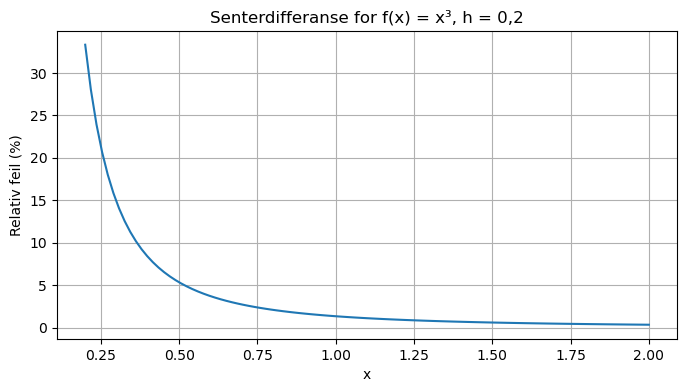

In [30]:
x_rel = np.linspace(0.2, 2, 101)
h_rel = 0.2
eksakt_rel = 3 * x_rel**2
senter_rel = (f(x_rel + h_rel) - f(x_rel - h_rel)) / (2 * h_rel)
relativ_feil = np.abs(senter_rel - eksakt_rel) / np.abs(eksakt_rel)

plt.figure(figsize=(8, 4))
plt.plot(x_rel, 100 * relativ_feil)
plt.xlabel("x")
plt.ylabel("Relativ feil (%)")
plt.title("Senterdifferanse for f(x) = x³, h = 0,2")
plt.grid()
plt.show()

Her er den absolutte senterfeilen konstant, mens den relative feilen avtar:
den eksakte deriverte blir større. **Absolutt og relativ feil forteller ulike ting.**

### Bro til oppgave 6 i øving 2

Der brukes funksjonen $g(x)=e^x+e^{-x}$, med eksakt derivert
$g'(x)=e^x-e^{-x}$. Det er samme fremgangsmåte, med en ny funksjon.
NumPy-funksjonen <code>np.exp</code> virker på både tall og arrays.

In [31]:
def g(x):
    return np.exp(x) + np.exp(-x)

x0 = 1.0
h = 0.2
g_senter = (g(x0 + h) - g(x0 - h)) / (2 * h)
g_eksakt = np.exp(x0) - np.exp(-x0)
print(f"Tilnærmet: {g_senter:.5f}")
print(f"Eksakt:    {g_eksakt:.5f}")
print(f"Absolutt feil: {abs(g_senter - g_eksakt):.5f}")

Tilnærmet: 2.36610
Eksakt:    2.35040
Absolutt feil: 0.01570


**Prøv senere:** Gjør beregningen for et array av x-verdier og tegn resultatet.
Også her er den eksakte deriverte null ved $x=0$.

<a id="oppsummering"></a>
## Hva har vi fått til?

Vi startet med et spørsmål om fart og endte med et numerisk eksperiment:

1. To funksjonsverdier gir en tilnærming til den deriverte.
2. Lister lagrer verdier; indeksering henter enkeltverdier.
3. NumPy-arrays lar oss beregne elementvis.
4. arange og linspace lager tallrekker.
5. Plotting gjør det mulig å sammenligne resultater.
6. Absolutt og relativ feil hjelper oss å tolke avvikene.

**Før du avslutter:** Bruk «Restart Kernel and Run All Cells» for å kontrollere
at beregningene ikke avhenger av gammel tilstand.

### Fredag med Truls

- Hvordan endrer feilen seg når vi varierer $h$?
- Hvorfor er et log–log-plott nyttig for dette?
- Hvorfor er ikke minst mulig $h$ alltid best?
- Eventuelt: hent posisjon og tid fra en fallvideo, og beregn hastighet og akselerasjon.

Slicing kommer senere sammen med numerisk integrasjon.

## Valgfri teaser: matriser fra matematikkfaget

Dere møter også matriser i matematikk. Et todimensjonalt array kan representere en matrise.
Legg merke til forskjellen mellom <code>*</code> og <code>@</code>. Dette trengs ikke for øving 2.

In [32]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[2, 0], [1, 2]])

print("Elementvis multiplikasjon:")
print(A * B)
print("Matrisemultiplikasjon:")
print(A @ B)

Elementvis multiplikasjon:
[[2 0]
 [3 8]]
Matrisemultiplikasjon:
[[ 4  4]
 [10  8]]


## Referanser og materiale

- [NumPy: introduksjon til arrays](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [Matplotlib: Pyplot-introduksjon](https://matplotlib.org/stable/tutorials/pyplot.html)
- [Kai Erik Hoffs forelesningsrepo](https://github.com/kaierih/INGA1002-Forelesninger)
- [Truls Helge Øis forelesningsrepo](https://github.com/trulsoi/Forelesninger)

Illustrasjonene av strekningsmålingen og de laserbaserte avstandsmålingene er hentet fra
figurene emneansvarlig la i forelesningsrepoet.